In [ ]:
#Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import seaborn as sns
import json
import os

In [ ]:
#Função para abrir arquivos .json com os resultados e retornar lista com dataframes

def prepare_dict_results(results_path, export=False):
    files = ['results_10_2.json', 'results_10_pca_2.json', 'results_1_2.json','results_1_pca_2.json', 'results_20_2.json', 'results_20_pca_2.json'] #arquivos com os resultados
    tags = ['10_khz', 'pca_10_khz', '1_khz', 'pca_1_khz', '20_khz', 'pca_20_khz'] #Lista com os nomes dos experimentos
    experiment = ['freq', 'freq+pca', 'freq', 'freq+pca', 'freq', 'freq+pca'] #Lista com os tipos de experimentos
    n_rows = [1200000, 1200000, 120000, 120000, 2400000, 2400000] #Lista com o número de amostras dos experimentos
    results = {} #Dicionário vazio
    for i in range(len(files)):
        file_path = os.path.join(results_path, files[i]) #Cria o caminho do arquivo
        with open(file_path, 'r') as file:
            data = json.load(file) #Abre o arquivo .json

        df = pd.DataFrame(data).T #Cria dataframe com os dados do arquivo .json, transpondo o dataframe
        df.columns = ['Matrix', 'accuracy', 'f1_score', 'time_train', 'time_pred'] #Define o nome das colunas
        df.index = df.index #Atualiza o índice do dataframe
        df['n_samples'] = n_rows[i] #Adiciona coluna de número de amostras
        df['experiment'] = experiment[i] #Adiciona coluna do tipo de experimento
        df = df.reset_index(names=['model']) #Transforma a coluna model no índice 
        df['model'] = df['model'].replace({'Gauss': 'GNB'}) #Atualiza o nome do model Gauss para GNB
        df.drop('Matrix', axis=1, inplace=True) #Exclui a coluna Matrix
        df = df.convert_dtypes() #Converte automáticamente os tipos de dados
        df['time_total'] = df['time_train'] + df['time_pred'] #Cria a coluna de time_total, somando os tempos de treinamento e de validação
        df.drop(['time_train', 'time_pred'], axis=1, inplace=True) #Exclui as colunas time_train e time_pred

        if export==True:
            df.to_csv(f'{results_path}/result_acc_{tags[i]}.csv', sep=';', decimal=',', index=False) #Exporta o dataframe criado em arquivo .csv caso a variável export seja igual a True

        results[tags[i]] = df #Adiciona o dataframe no dicionário

    return results #Retorna dicionário com dataframes dos resultados

In [ ]:
results = prepare_dict_results('Results_acc_time_2', export=True) #Chama a função e armazena o dicionário com os dataframes, exportando em arquivo .csv

In [ ]:
df_join = pd.concat(results) #Junta os dataframes do dicionário em um só

In [ ]:
order_titles = ['Redução de Frequência', 'Redução de Frequência + PCA'] #Cria lista com os títulos dos gráficos

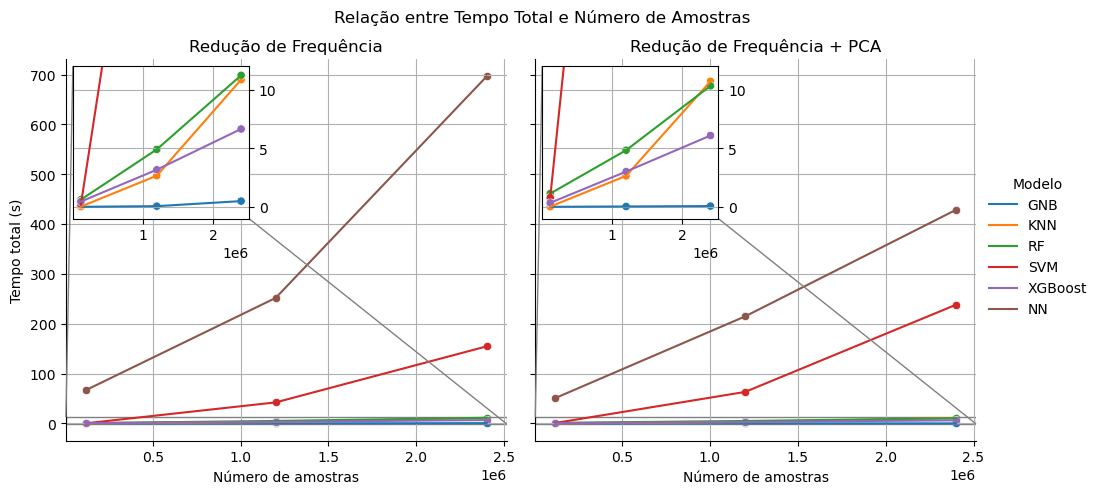

In [ ]:
f = sns.FacetGrid(df_join, col='experiment', hue='model', height=5) #Cria FacetGrid com o dataframe, filtrando pela coluna experiment e pela coluna model
f.map(sns.scatterplot, 'n_samples', 'time_total') #Cria gráfico de dispersão com as colunas n_samples e time_total
f.map(sns.lineplot, 'n_samples', 'time_total') #Cria gráfico de linha com as colunas n_samples e time_total
for experiment, ax in f.axes_dict.items():
    ax.grid() #Adiciona linhas de grade no gráfico
    subset = df_join[df_join['experiment']==experiment] #Cria dataframe filtrando de acordo com o experimento

    ax_inset = inset_axes(ax, width='40%', height='40%', loc='upper left') #Cria gráfico menor dentro do gráfico principal
    sns.lineplot(x = 'n_samples', y = 'time_total',
             data=subset, hue='model', errorbar=None, ax=ax_inset) #Adiciona gráfico de linha no gráfico menor, utilizando as colunas n_samples e time_total do dataframe filtrado, 
                                                                   #separando de acordo com a coluna model
    sns.scatterplot(x = 'n_samples', y = 'time_total',
             data=subset, hue='model', ax=ax_inset) #Adiciona gráfico de dispersão no gráfico menor, utilizando as colunas n_samples e time_total do dataframe filtrado, 
                                                    #separando de acordo com a coluna model
    ax_inset.set_ylim(-1,12) #Define os limites do eixo y
    mark_inset(ax, ax_inset, loc1=2, loc2=4, fc='none', ec='0.5') #Cria caixa para cercar os dados que foram ampliados no gráfico menor
    ax_inset.legend().remove() #Remove a legenda do gráfico menor
    ax_inset.yaxis.tick_right() #Move a posição dos valores do eixo y para a direita
    ax_inset.set(ylabel=None) #Remove o título do eixo y do gráfico menor
    ax_inset.set(xlabel=None) #Remove o título do eixo x do gráfico menor
    ax_inset.grid() #Adiciona linha de grade no gráfico menor

for idx, ax in enumerate(f.axes.flat):
    ax.set_title(order_titles[idx]) #Altera o título dos gráficos

f.fig.suptitle('Relação entre Tempo Total e Número de Amostras') #Cria título da imagem com os gráficos
f.fig.subplots_adjust(top=0.88) #Ajusta a posição do título
f.add_legend() #Adiciona legenda
f.legend.set_title('Modelo') #Altera o título da legenda para Modelo
f.set_xlabels('Número de amostras') #Define o título do eixo x para Número de Amostras
f.set_ylabels('Tempo total (s)') #Define o título do eixo y para Tempo Total (s)
plt.savefig('Results_acc_time_2/Grid_plot_samples_time_inset.png') #Salva a figura em arquivo .png

plt.show() #Mostra a figura